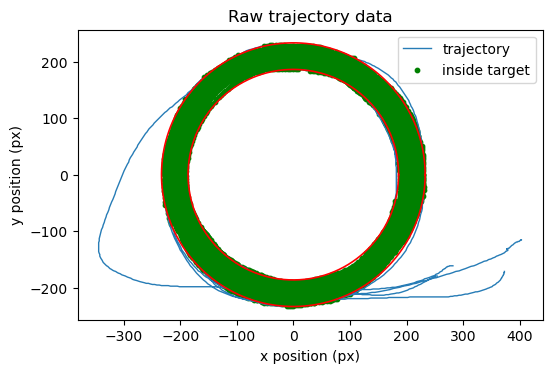

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# ====================================================
# FILE PATHS
# ====================================================

RAW_FILE    = "../data/001MoDe_R1.csv" #continuous mouse trajectory
MARKER_FILE = "../data/001MoDe_R1.marker.csv" #event timestamps (DoRecord / DoPause)

#everything is wrapped inside a function to minimize global variables usage 

def load_metadata(RAW_FILE):
    # ====================================================
    # PARSING METADATA FROM FIRST LINE OF RAW FILE
    # ====================================================
    with open(RAW_FILE, "r") as f:
        metadata_line = f.readline().strip()

    # Metadata is written as "key value;key value;..."
    metadata_entries = metadata_line.split(";")

    # Initialize fields
    center_x = 0.0
    center_y = 0.0
    radius_inner = 0.0
    radius_outer = 0.0

    # Extract numeric values from metadata
    for entry in metadata_entries:
        tokens = entry.split()
        if len(tokens) != 2:
            continue
        key, val = tokens
        if key == "centerX":
            center_x = float(val)
        elif key == "centerY":
            center_y = float(val)
        elif key == "internalRadius":
            radius_inner = float(val)
        elif key == "externalRadius":
            radius_outer = float(val)

    # important ! If numeries values are hardcoded (eg, "center_x = 552") 
    # it won't carry over if another file w/ different metadata is used.

    # importing the radius and tolerance for later use
    task_radius = 0.0
    task_tolerance = 0.0

    for entry in metadata_entries: #same as before, taking them directly from the metadata
        tokens = entry.split()
        if len(tokens) != 2:
            continue
        key, val = tokens
        if key == "taskRadius":
            task_radius = float(val)
        elif key == "taskTolerance":
            task_tolerance = float(val)

    return center_x, center_y, radius_inner, radius_outer, task_radius, task_tolerance
def load_markers(MARKER_FILE):
    # ====================================================
    # PARSE EVENT MARKERS (DoRecord / DoPause)
    # ====================================================
    record_starts = []
    record_stops  = []

    with open(MARKER_FILE, "r") as f:
        for line in f:
            if "," not in line:
                continue

            parts = line.strip().split(",") # e.g., ["#Marker", "123456", "DoRecord"]
            if len(parts) < 3: 
                continue

            # parts[1] = timestamp, we keep only pure integers
            ts_str = parts[1]
            if not ts_str.isdigit():
                continue

            timestamp = int(ts_str) # in milliseconds
            event     = parts[2] # e.g., "DoRecord" or "DoPause"

            if "DoRecord" in event:
                record_starts.append(timestamp)
            elif "DoPause" in event:
                record_stops.append(timestamp)

    return np.array(record_starts), np.array(record_stops)
def load_trajectory(RAW_FILE, center_x, center_y, record_starts, record_stops):
    # ====================================================
    # LOAD TRAJECTORY DATA 
    # ====================================================
    # Line structure after skip:
    # time, mouseX, mouseY, inTargetFlag
    raw_data = np.genfromtxt(RAW_FILE, delimiter=",", skip_header=4) #skip the metadata + 3 header lines
    time_all, mouse_x_all, mouse_y_all, inside_target_all = raw_data.T

    # Recenter into target coordinate system
    x_all = mouse_x_all - center_x
    y_all = -(mouse_y_all - center_y)  # flip Y-axis, otherwise upside-down

    # ====================================================
    # KEEP ONLY VALID RECORDING SEGMENTS
    # ====================================================
    # manually adjusting the mask is needed - some corrupted timestamps slept throught ( "0.0.0.0.0")
    timestamp_valid = time_all > 1e12 #keep only valid timestamps (> 1 trillion ms, since it's that unix epoch time in seconds)

    valid_mask = np.zeros_like(time_all, dtype=bool) #build the mask from DoRecord / DoPause events

    for start, stop in zip(record_starts, record_stops):
        valid_mask |= (time_all >= (start - 30)) & (time_all <= stop)

    # combine the masks
    valid_mask &= timestamp_valid

    # apply the final mask
    x_valid = x_all[valid_mask] #filtered x positions
    y_valid = y_all[valid_mask] #filtered y positions
    t_valid = time_all[valid_mask] #filtered timestamps
    inside_mask_valid = inside_target_all.astype(bool)[valid_mask]     # mask aligned with x_valid, y_valid

    return x_valid, y_valid, t_valid, inside_mask_valid
def plot_raw_trajectory(x_valid, y_valid, inside_mask_valid):
    # ====================================================
    # PLOT TRAJECTORY + DONUT
    # ====================================================
    plt.figure(figsize=(6, 6))

    # compute radii only for inside-target samples
    r_inside = np.sqrt(x_valid[inside_mask_valid]**2 + y_valid[inside_mask_valid]**2)

    # Compute empirical radii
    inner_r = r_inside.min()
    outer_r = r_inside.max()

    theta = np.linspace(0, 2*np.pi, 512)
    circle_inner_x = inner_r * np.cos(theta)
    circle_inner_y = inner_r * np.sin(theta)
    circle_outer_x = outer_r * np.cos(theta)
    circle_outer_y = outer_r * np.sin(theta)

    inside_mask = inside_mask_valid        # rename consistently
    outside_mask = ~inside_mask

    # construct blue trajectory with discontinuation (convoluted but otherwise it connect the dots THRU the target area)
    x_blue = x_valid[outside_mask].copy()
    y_blue = y_valid[outside_mask].copy()

    # threshold for cutting the line (in pixels), removes the mouse movements that are too fast to be real or that are cutting thru.
    jump = 30 # pixels, empirical by trial and error

    for i in range(1, len(x_blue)):
        dx = x_blue[i] - x_blue[i-1]
        dy = y_blue[i] - y_blue[i-1]
        if np.hypot(dx, dy) > jump:
            x_blue[i] = np.nan
            y_blue[i] = np.nan

    plt.plot(
        x_blue, y_blue,
        color="#277cb6", # it's the hex code for the blue i think was used ?
        linewidth=1,
        label="trajectory"
    )
    # it plots the blue line only for the outside target points, with NaNs computed earlier to break the line when jumps are too large.

    # Inside target (green dots)
    plt.scatter(
        x_valid[inside_mask],
        y_valid[inside_mask],
        s=10,
        color="green",
        label="inside target"
    )

    # 3) red annulus (the inner and outer red circles, has to be on top)
    plt.plot(circle_inner_x, circle_inner_y, color="red", linewidth=1.2, zorder=4)
    plt.plot(circle_outer_x, circle_outer_y, color="red", linewidth=1.2, zorder=4)

    plt.gca().set_aspect("equal")
    plt.xlabel("x position (px)")
    plt.ylabel("y position (px)")
    plt.title("Raw trajectory data")
    plt.legend()
    plt.show()

center_x, center_y, radius_inner, radius_outer, task_radius, task_tolerance = load_metadata(RAW_FILE)
record_starts, record_stops = load_markers(MARKER_FILE)
x_valid, y_valid, t_valid, inside_mask_valid = load_trajectory(RAW_FILE, center_x, center_y, record_starts, record_stops)

plot_raw_trajectory(x_valid, y_valid, inside_mask_valid)

# ====================================================
# TODO
# ====================================================
# fix plotting --> inside line & legends / fix name confusion w/ previous itterations


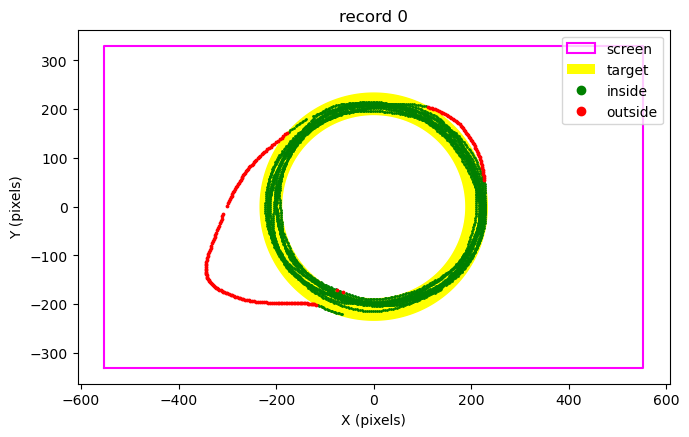

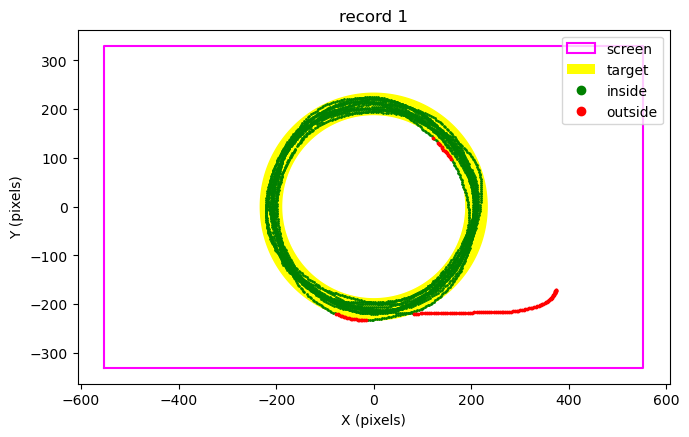

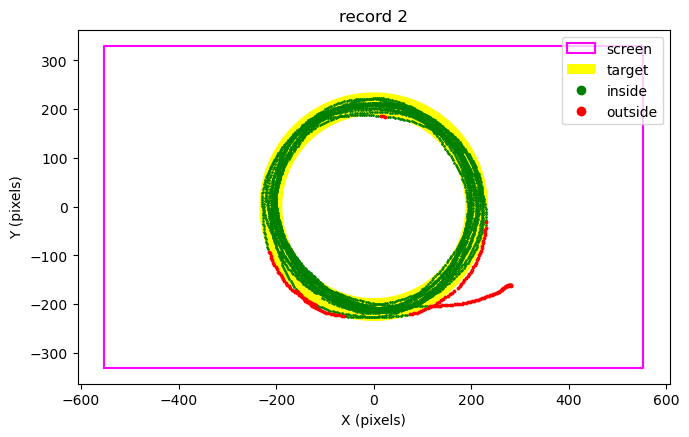

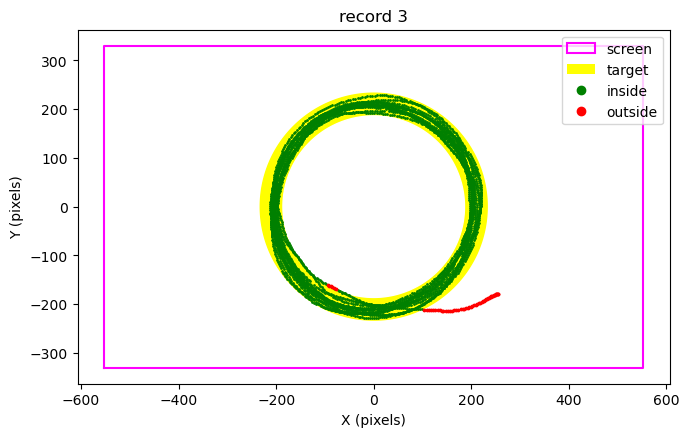

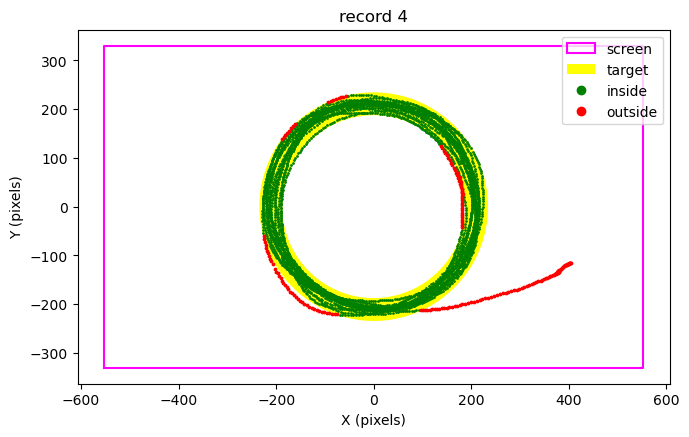

In [3]:
# ====================================================
# INDIVIDUAL RECORDS PLOTTING
# ====================================================

from matplotlib.lines import Line2D #needed for CREATE the custom shape legend (rectangles)
from matplotlib.patches import Patch #needed to INSERT the colored patches in the legend

#everything is wrapped inside a function so we can call it multiple times for different records 
# and to avoid code repetition & issues during the merge)
# i = 0 # record index

def plot_indiv_record(i):
# ====================================================
# DATA SELECTION (ONLY FOR RECORD i)
# ====================================================
    start = record_starts[i]
    stop  = record_stops[i]

    # Keep only samples belonging to this record
    mask = (t_valid >= start) & (t_valid <= stop)
    x_rec = x_valid[mask]
    y_rec = y_valid[mask]
    inside_rec = inside_mask_valid[mask]

# ====================================================
# FIGURE SETUP
# ====================================================
    fig, ax = plt.subplots(figsize=(7,6))
    ax.set_aspect("equal")

    # the magenta screen rectangle
    screen_w = center_x * 2
    screen_h = center_y * 2

    ax.plot(
        [-screen_w/2,  screen_w/2,  screen_w/2, -screen_w/2, -screen_w/2],
        [-screen_h/2, -screen_h/2,  screen_h/2,  screen_h/2, -screen_h/2],
        color="magenta",
        linewidth=1.5,
        label="screen"
    )
    # inside donut (convoluted ++ but works)
    # compute radii of inside samples
    r = np.sqrt(x_rec[inside_rec]**2 + y_rec[inside_rec]**2) 
    inner = r.min() 
    outer = r.max()

    theta = np.linspace(0, 2*np.pi, 512) 

    # Fill INSIDE the ring
    ax.fill(outer*np.cos(theta),
            outer*np.sin(theta),
            color="yellow",
            alpha=1,
            zorder=1)
    # Cut out inner circle (just paint it white again)
    ax.fill(inner*np.cos(theta),
            inner*np.sin(theta),
            color="white",
            zorder=2)


    # The Inside points
    ax.scatter(x_rec[inside_rec],  y_rec[inside_rec],
            s=1, color="green", label="inside", zorder=5) #inside target (green)

    ax.scatter(x_rec[~inside_rec], y_rec[~inside_rec],
            s=3, color="red",   label="outside", zorder=6) #outside of the target (red)




# ====================================================
# FIGURE LEGEND
# ====================================================
#custom shapes for the legend
    screen_rect  = Patch(facecolor='none', edgecolor='magenta', linewidth=1.5, label='screen')
    yellow_patch = Patch(facecolor='yellow', edgecolor='none', label='target')
    green_dot    = Line2D([], [], marker='o', color='green', linestyle='None', label='inside')
    red_dot      = Line2D([], [], marker='o', color='red',   linestyle='None', label='outside')
#calling the custom shapes
    plt.legend(
        handles=[screen_rect, yellow_patch, green_dot, red_dot],
        loc='upper right'
    )
    ax.set_title(f"record {i}")
    ax.set_xlabel("X (pixels)")
    ax.set_ylabel("Y (pixels)")
    plt.tight_layout()
    plt.show()

plot_indiv_record(0)
plot_indiv_record(1)
plot_indiv_record(2)
plot_indiv_record(3)
plot_indiv_record(4)